In [5]:
import boto3
import io
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:4566",
    region_name="us-east-1",
    aws_access_key_id="test",
    aws_secret_access_key="test"
)

def read_gold(table_name):
    resp = s3.list_objects_v2(Bucket="data-lake-gold", Prefix=table_name)
    key  = resp["Contents"][0]["Key"]
    obj  = s3.get_object(Bucket="data-lake-gold", Key=key)
    buf  = io.BytesIO(obj["Body"].read())
    return pq.read_table(buf).to_pandas()

print("Conexión OK")


Conexión OK


In [6]:
plt.rcParams.update({
    "figure.facecolor":  "#1e1e2e",
    "axes.facecolor":    "#1e1e2e",
    "axes.edgecolor":    "#444466",
    "axes.labelcolor":   "#cdd6f4",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   "#cdd6f4",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "xtick.color":       "#cdd6f4",
    "ytick.color":       "#cdd6f4",
    "text.color":        "#cdd6f4",
    "font.family":       "sans-serif",
    "grid.color":        "#313244",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
})

COLORS = ["#89b4fa", "#a6e3a1", "#fab387", "#f38ba8", "#cba6f7"]

print("Dark mode OK")

Dark mode OK


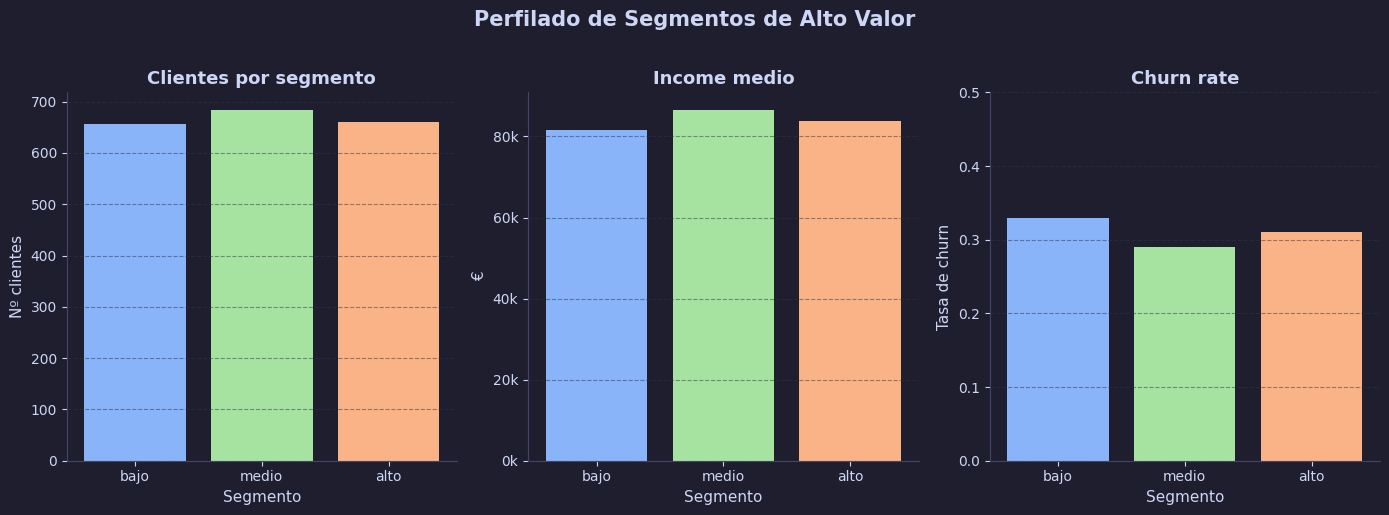

Guardado: marketing_segmentos.png


In [8]:
df_seg = read_gold("marketing_segment_alto_valor")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#1e1e2e")
fig.suptitle("Perfilado de Segmentos de Alto Valor", fontsize=15, fontweight="bold", color="#cdd6f4", y=1.02)

# Número de clientes
axes[0].bar(df_seg["segmento_valor"], df_seg["num_clientes"], color=COLORS[:3])
axes[0].set_title("Clientes por segmento")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Nº clientes")
axes[0].yaxis.grid(True)

# Avg income
axes[1].bar(df_seg["segmento_valor"], df_seg["avg_income"], color=COLORS[:3])
axes[1].set_title("Income medio")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("€")
axes[1].yaxis.grid(True)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Churn rate
axes[2].bar(df_seg["segmento_valor"], df_seg["churn_rate"], color=COLORS[:3])
axes[2].set_title("Churn rate")
axes[2].set_xlabel("Segmento")
axes[2].set_ylabel("Tasa de churn")
axes[2].yaxis.grid(True)
axes[2].set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig("marketing_segmentos.png", dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.show()
print("Guardado: marketing_segmentos.png")

## 1. Segmentos de Valor — ¿Dónde está realmente el riesgo?

El dataset divide a los 2.000 clientes en tres segmentos según su **Spending Score**:
clientes de gasto bajo, medio y alto.

## 🔎

- Los tres segmentos tienen un **tamaño similar** (~650-680 clientes cada uno).
  No hay un segmento dominante — la base de clientes está equilibrada.

- El **income medio** es prácticamente igual en los tres segmentos (81k-86k €).
  Ganar más dinero no predice cuánto se gasta. El spending score es independiente
  del income — hay clientes de renta alta que gastan poco y viceversa.

- El **churn más bajo no está en el segmento alto (0.31) sino en el medio (0.29)**.
  El cliente de gasto alto es paradójicamente menos fiel que el medio.


_El **segmento medio** es el activo **más estable de la compañía**. Marketing tiende a
perseguir al cliente de alto valor, pero los datos sugieren que defender y hacer
crecer el segmento medio tiene mejor retorno en retención. Antes de invertir en
captación de clientes premium, **conviene preguntarse por qué los que ya son premium
se van más.**_

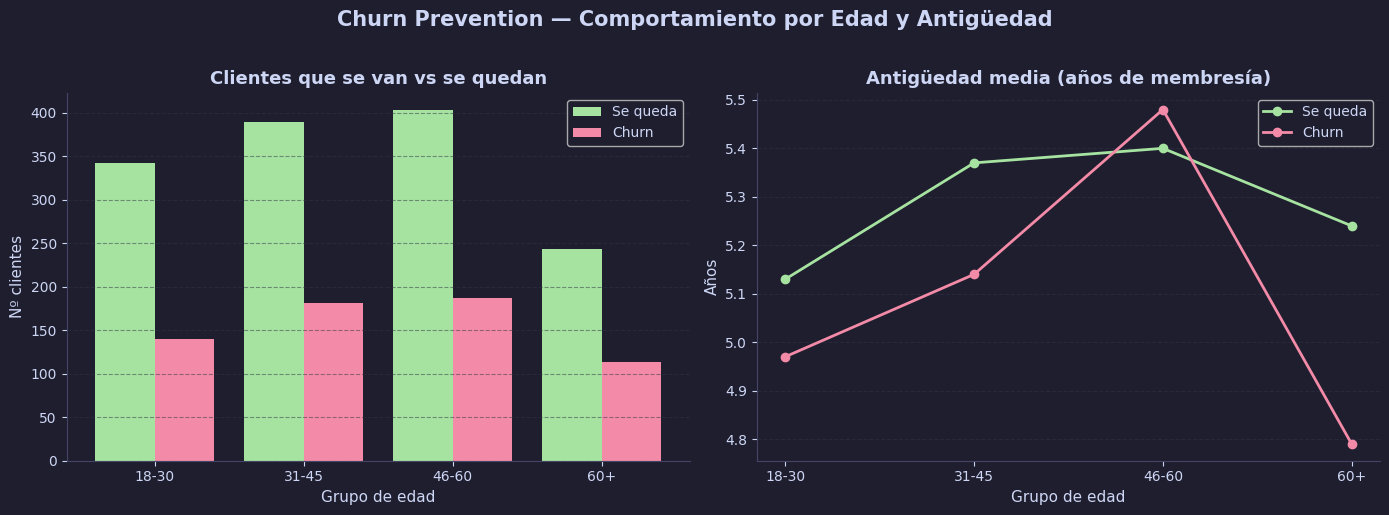

Guardado: retencion_churn.png


In [9]:
df_churn = read_gold("retencion_churn_prevention")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#1e1e2e")
fig.suptitle("Churn Prevention — Comportamiento por Edad y Antigüedad", fontsize=15, fontweight="bold", color="#cdd6f4", y=1.02)

# Nº clientes churn vs no churn por grupo de edad
age_groups = df_churn["age_group"].unique()
x = range(len(age_groups))
no_churn = df_churn[df_churn["churn"] == 0]["num_clientes"].values
si_churn = df_churn[df_churn["churn"] == 1]["num_clientes"].values

axes[0].bar([i - 0.2 for i in x], no_churn, width=0.4, label="Se queda", color=COLORS[1])
axes[0].bar([i + 0.2 for i in x], si_churn, width=0.4, label="Churn",    color=COLORS[3])
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(age_groups)
axes[0].set_title("Clientes que se van vs se quedan")
axes[0].set_xlabel("Grupo de edad")
axes[0].set_ylabel("Nº clientes")
axes[0].yaxis.grid(True)
axes[0].legend()

# Avg membership years churn vs no churn
mem_no_churn = df_churn[df_churn["churn"] == 0]["avg_membership_years"].values
mem_si_churn = df_churn[df_churn["churn"] == 1]["avg_membership_years"].values

axes[1].plot(age_groups, mem_no_churn, marker="o", color=COLORS[1], label="Se queda", linewidth=2)
axes[1].plot(age_groups, mem_si_churn, marker="o", color=COLORS[3], label="Churn",    linewidth=2)
axes[1].set_title("Antigüedad media (años de membresía)")
axes[1].set_xlabel("Grupo de edad")
axes[1].set_ylabel("Años")
axes[1].yaxis.grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("retencion_churn.png", dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.show()
print("Guardado: retencion_churn.png")

## 2. Churn Prevention — ¿Quién se va y por qué importa la antigüedad?

El **grupo de edad del cliente** y cuántos **años** lleva
**como miembro**. La antigüedad es uno de los predictores más clásicos de retención
— a más tiempo, más difícil es irse.

## 🔎

- En **todos los grupos de edad** son más los clientes que se quedan respecto a los que se van.
  El ratio es aproximadamente 2:1 en todos los segmentos — no hay un grupo
  especialmente problemático en volumen.

- En el gráfico de líneas, los clientes que **se quedan tienen consistentemente
  más años de membresía** que los que hacen churn — excepto en el grupo **46-60**,
  donde ocurre lo contrario (5.48 años los que se van vs 5.40 los que se quedan).

_La antigüedad protege la retención en casi todos los segmentos — tiene sentido,
el coste de cambio aumenta con el tiempo. Pero el segmento 46-60 rompe esa regla:
son clientes veteranos que aun así deciden irse. Esto sugiere un problema que
no es de hábito ni de inercia, sino de **propuesta de valor**. Es el segmento que
merece una investigación cualitativa — encuestas, entrevistas, análisis de
tickets de soporte. Los datos nos dicen que algo falla; no nos dicen qué._

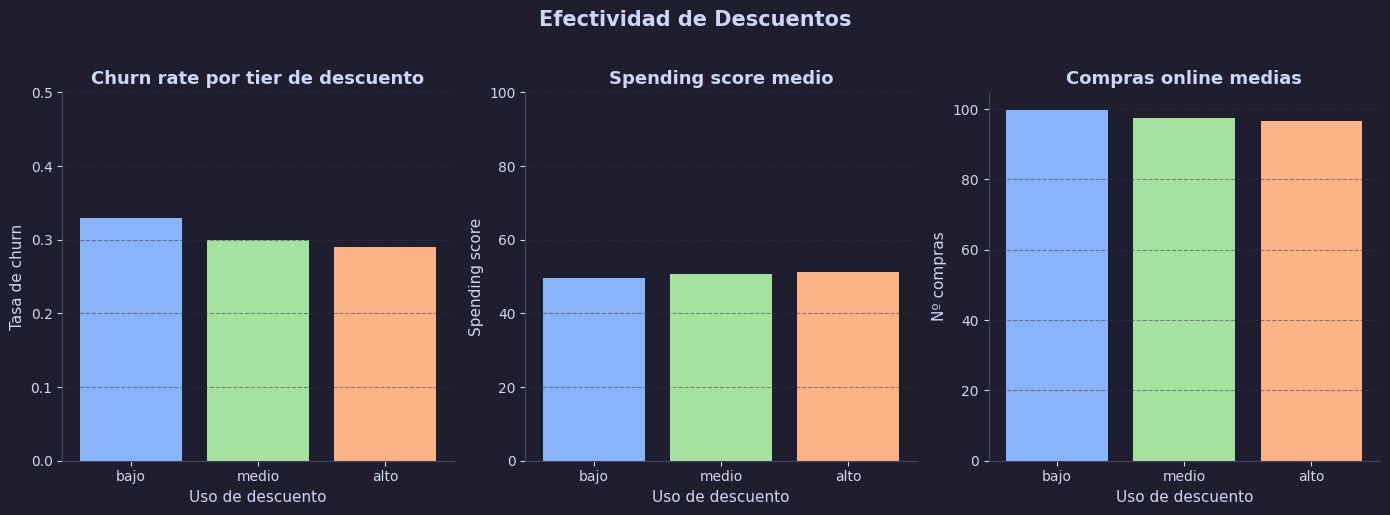

Guardado: descuentos_efectividad.png


In [10]:
df_disc = read_gold("promociones_discount_effect")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#1e1e2e")
fig.suptitle("Efectividad de Descuentos", fontsize=15, fontweight="bold", color="#cdd6f4", y=1.02)

# Churn rate por tier de descuento
axes[0].bar(df_disc["discount_tier"], df_disc["churn_rate"], color=COLORS[:3])
axes[0].set_title("Churn rate por tier de descuento")
axes[0].set_xlabel("Uso de descuento")
axes[0].set_ylabel("Tasa de churn")
axes[0].set_ylim(0, 0.5)
axes[0].yaxis.grid(True)

# Spending score por tier
axes[1].bar(df_disc["discount_tier"], df_disc["avg_spending_score"], color=COLORS[:3])
axes[1].set_title("Spending score medio")
axes[1].set_xlabel("Uso de descuento")
axes[1].set_ylabel("Spending score")
axes[1].set_ylim(0, 100)
axes[1].yaxis.grid(True)

# Online purchases por tier
axes[2].bar(df_disc["discount_tier"], df_disc["avg_online_purchases"], color=COLORS[:3])
axes[2].set_title("Compras online medias")
axes[2].set_xlabel("Uso de descuento")
axes[2].set_ylabel("Nº compras")
axes[2].yaxis.grid(True)

plt.tight_layout()
plt.savefig("descuentos_efectividad.png", dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.show()
print("Guardado: descuentos_efectividad.png")

## 3. Descuentos — ¿Fidelizan o solo mueven volumen?

La pregunta de negocio es directa: ¿los descuentos retienen
clientes o simplemente atraen compradores oportunistas?

## 🔎


- El **churn rate apenas varía** entre tiers: 0.33 en bajo, 0.30 en medio, 0.29 en alto.
  Una diferencia de 0.04 entre el tier más bajo y el más alto es estadísticamente
  insignificante. Los descuentos no mueven la aguja en retención.

- El **spending score sube ligeramente** con el uso de descuentos (49.54 → 51.21).
  Los descuentos generan algo más de actividad de compra, pero de forma marginal.

- Las **compras online bajan** a mayor uso de descuento (99.76 → 96.53).
  El cliente que más usa descuentos no es necesariamente el que más compra online
  — posiblemente compra en canales físicos o espera a promociones para comprar.

_Los descuentos son un instrumento de volumen puntual, no de fidelización. **Invertir
presupuesto de marketing en descuentos esperando reducir el churn es un error que
los datos desmienten**. Para mayor retención, los descuentos
deberían reservarse para reactivación de clientes inactivos o captación, no para
defender la base activa._

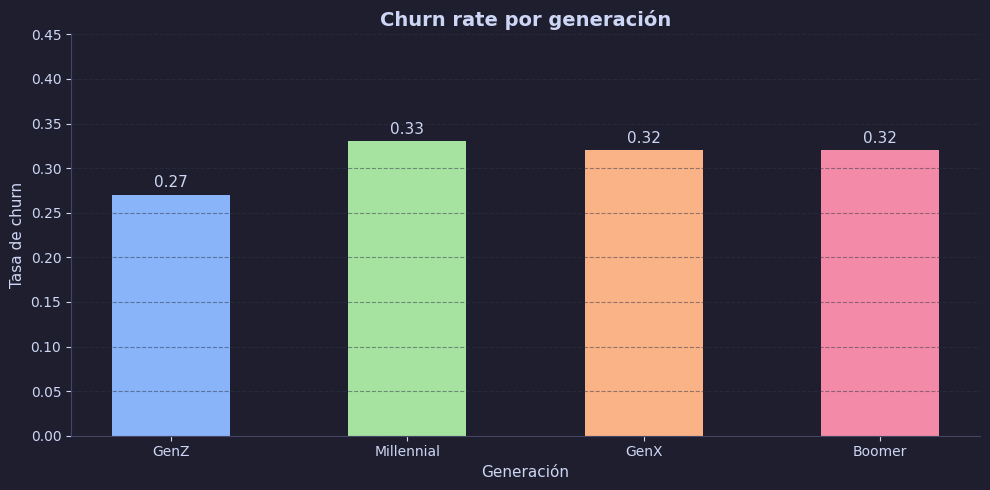

Guardado: generacional_gaps.png


In [13]:
df_gen = read_gold("product_generational_gaps")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e2e")

bars = ax.bar(df_gen["generacion"], df_gen["churn_rate"], color=COLORS[:4], width=0.5)

# Etiquetas encima de cada barra
for bar, val in zip(bars, df_gen["churn_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.2f}", ha="center", va="bottom", color="#cdd6f4", fontsize=11)

ax.set_title("Churn rate por generación", fontsize=14, fontweight="bold", color="#cdd6f4")
ax.set_xlabel("Generación")
ax.set_ylabel("Tasa de churn")
ax.set_ylim(0, 0.45)
ax.yaxis.grid(True)

plt.tight_layout()
plt.savefig("generacional_gaps.png", dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.show()
print("Guardado: generacional_gaps.png")

## 4. Brechas Generacionales — ¿Quién es el cliente más fiel?

Segmentamos por generación: GenZ (hasta 28 años), Millennials (29-44),
GenX (45-60) y Boomers (60+). La pregunta es si la generación predice
la lealtad al producto.

## 🔎

- **GenZ tiene el churn más bajo (0.27)** — son el segmento más fiel,
  contraintuitivo para una generación que se percibe como volátil
  y con baja tolerancia a productos que no les convencen.

- **Millennials, GenX y Boomers se agrupan en torno a 0.32** — no hay
  diferencia significativa entre ellos. La generación por sí sola
  no explica el churn en estos tres grupos.

- La brecha real es **GenZ vs todos los demás**, no entre adultos
  de distintas edades.

_GenZ no solo compra más online — también se queda más. Esto sugiere
que el producto encaja especialmente bien con sus hábitos digitales
o su momento vital. La pregunta estratégica no es cómo retener
Millennials o Boomers de forma diferenciada entre sí — es entender
**qué hace que GenZ sea tan fiel y si eso es replicable** como propuesta
de valor para el resto._

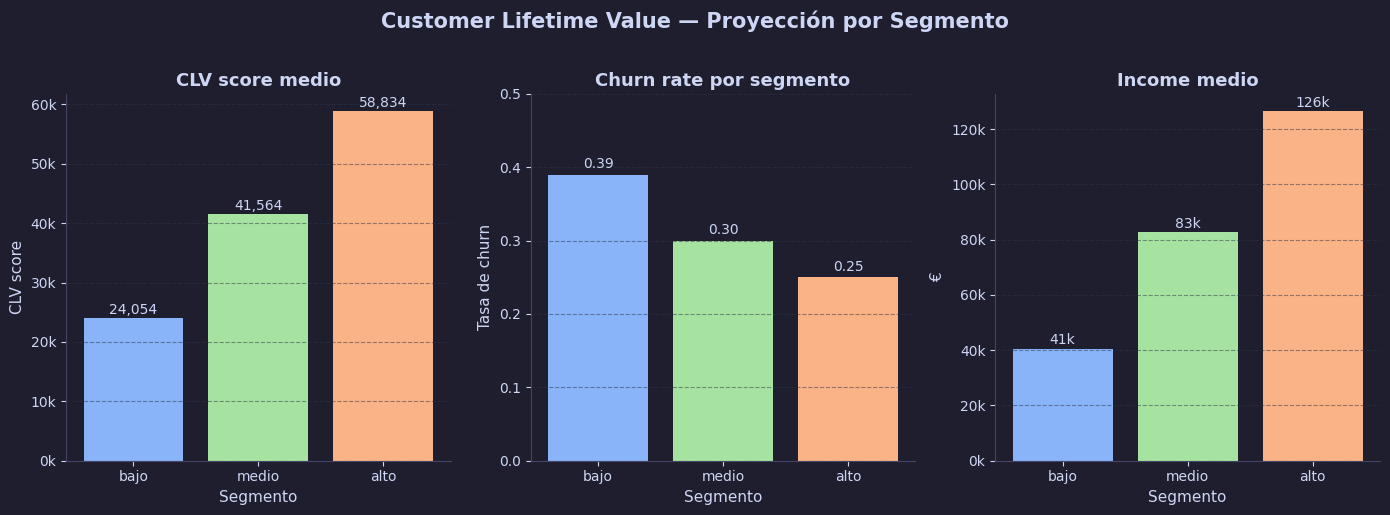

Guardado: clv_projection.png


In [14]:
df_clv = read_gold("clevel_clv_projection")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#1e1e2e")
fig.suptitle("Customer Lifetime Value — Proyección por Segmento", fontsize=15, fontweight="bold", color="#cdd6f4", y=1.02)

# CLV score medio
axes[0].bar(df_clv["clv_segment"], df_clv["avg_clv_score"], color=COLORS[:3])
for bar, val in zip(axes[0].patches, df_clv["avg_clv_score"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f"{val:,.0f}", ha="center", va="bottom", color="#cdd6f4", fontsize=10)
axes[0].set_title("CLV score medio")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("CLV score")
axes[0].yaxis.grid(True)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Churn rate
axes[1].bar(df_clv["clv_segment"], df_clv["churn_rate"], color=COLORS[:3])
for bar, val in zip(axes[1].patches, df_clv["churn_rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.2f}", ha="center", va="bottom", color="#cdd6f4", fontsize=10)
axes[1].set_title("Churn rate por segmento")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("Tasa de churn")
axes[1].set_ylim(0, 0.5)
axes[1].yaxis.grid(True)

# Income medio
axes[2].bar(df_clv["clv_segment"], df_clv["avg_income"], color=COLORS[:3])
for bar, val in zip(axes[2].patches, df_clv["avg_income"]):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f"{val/1000:.0f}k", ha="center", va="bottom", color="#cdd6f4", fontsize=10)
axes[2].set_title("Income medio")
axes[2].set_xlabel("Segmento")
axes[2].set_ylabel("€")
axes[2].yaxis.grid(True)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("clv_projection.png", dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.show()
print("Guardado: clv_projection.png")

## 5. 👉 Valor de vida del cliente — ¿Dónde está el valor real del negocio?

Calculamos un CLV (Customer Lifetime Value) score compuesto ponderando income,
spending, antigüedad y penalizando el churn.

## 🔎

- Los tres segmentos cuentan una historia limpia y escalonada. El segmento
  **alto genera más del doble de CLV** que el bajo (58k vs 24k). La distancia
  entre segmentos es grande y está bien definida.

- El **churn cae conforme sube el CLV**: 0.39 en bajo, 0.30 en medio, 0.25
  en alto. Los clientes más valiosos son también los más fieles — aquí sí
  se cumple la intuición.

- El **income explica gran parte del CLV**: 40k en bajo, 82k en medio, 126k
  en alto. La capacidad económica del cliente es el predictor más fuerte
  de su valor a largo plazo.

_La palanca más poderosa no está en el segmento alto — ese ya funciona solo.
Está en el segmento bajo: 445 clientes con churn del 39% que se van antes
de generar valor. Reducir ese churn del 0.39 al 0.30 tendría un impacto
directo en el CLV agregado del negocio mayor que cualquier campaña de
captación de clientes premium. Retener
vale más que adquirir._